<a href="https://colab.research.google.com/github/kshitijagame-tech/rabtech-aiml-customer-churn/blob/main/Task_5_Deep_Learning_NLP_Text_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.20.0
All libraries imported successfully!


In [3]:
# Vocabulary size
vocab_size = 10000

# Load IMDB movie review dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Dataset loaded successfully!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Vocabulary size:", vocab_size)

print("\nFirst review label:")
print("Positive" if y_train[0] == 1 else "Negative")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully!
Training samples: 25000
Testing samples: 25000
Vocabulary size: 10000

First review label:
Positive


In [4]:
max_length = 200

X_train_padded = pad_sequences(
    X_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Text preprocessing completed!")
print("Training data shape:", X_train_padded.shape)
print("Testing data shape:", X_test_padded.shape)

Text preprocessing completed!
Training data shape: (25000, 200)
Testing data shape: (25000, 200)


In [5]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_padded,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training and validation split completed!")
print("Training samples:", len(X_train_final))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test_padded))

Training and validation split completed!
Training samples: 20000
Validation samples: 5000
Test samples: 25000


In [6]:
model = models.Sequential([
    layers.Embedding(
        input_dim=vocab_size,
        output_dim=64
    ),

    layers.GlobalAveragePooling1D(),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Deep Learning model created successfully!")

model.summary()

Deep Learning model created successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

print("Early Stopping callback created successfully!")

Early Stopping callback created successfully!


In [8]:
history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1
)

print("Training completed successfully!")

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.7258 - loss: 0.5539 - val_accuracy: 0.5010 - val_loss: 0.6696
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8705 - loss: 0.3169 - val_accuracy: 0.8190 - val_loss: 0.5454
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9050 - loss: 0.2428 - val_accuracy: 0.7776 - val_loss: 0.4429
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.9218 - loss: 0.2048 - val_accuracy: 0.8604 - val_loss: 0.3510
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9301 - loss: 0.1836 - val_accuracy: 0.8046 - val_loss: 0.4819
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9390 - loss: 0.1579 - val_accuracy: 0.8360 - val_loss: 0.5012
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9492 - loss: 0.1367 - val_accuracy: 0.8350 - val_loss: 0.5329
Training completed successfully!


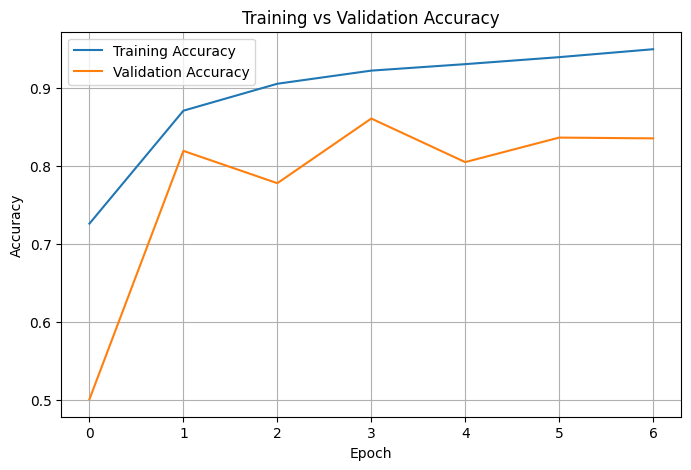

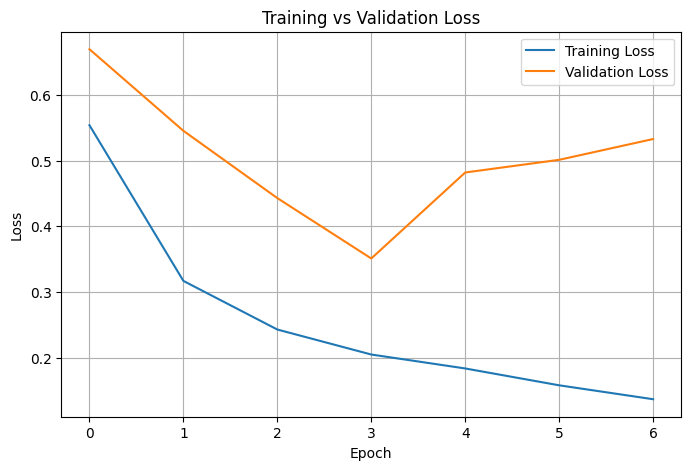

In [9]:
# Get training history
history_dict = history.history

# Accuracy curve
plt.figure(figsize=(8, 5))

plt.plot(history_dict["accuracy"], label="Training Accuracy")
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Loss curve
plt.figure(figsize=(8, 5))

plt.plot(history_dict["loss"], label="Training Loss")
plt.plot(history_dict["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test,
    verbose=0
)

print("========== MODEL EVALUATION ==========")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))
print("Test Accuracy (%):", round(test_accuracy * 100, 2), "%")

========== MODEL EVALUATION ==========
Test Loss: 0.3652
Test Accuracy: 0.8444
Test Accuracy (%): 84.44 %


In [11]:
test_loss, test_accuracy = model.evaluate(
    X_test_padded,
    y_test,
    verbose=0
)

print("========== MODEL EVALUATION ==========")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))
print("Test Accuracy (%):", round(test_accuracy * 100, 2), "%")

========== MODEL EVALUATION ==========
Test Loss: 0.3652
Test Accuracy: 0.8444
Test Accuracy (%): 84.44 %


In [12]:
# Get IMDB word index
word_index = imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()

    encoded = []

    for word in words:
        index = word_index.get(word)

        if index is not None and index < vocab_size:
            encoded.append(index + 3)
        else:
            encoded.append(2)  # Unknown word

    return pad_sequences(
        [encoded],
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

# Unseen review
new_review = "This movie was amazing and I really enjoyed it"

# Convert text to sequence
new_review_padded = encode_review(new_review)

# Prediction
prediction = model.predict(new_review_padded, verbose=0)[0][0]

if prediction >= 0.5:
    sentiment = "Positive"
    confidence = prediction
else:
    sentiment = "Negative"
    confidence = 1 - prediction

print("========== UNSEEN TEXT PREDICTION ==========")
print("Review:", new_review)
print("Predicted Sentiment:", sentiment)
print("Confidence:", round(confidence * 100, 2), "%")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
========== UNSEEN TEXT PREDICTION ==========
Review: This movie was amazing and I really enjoyed it
Predicted Sentiment: Positive
Confidence: 82.8 %


In [13]:
# Another unseen review
new_review = "This movie was boring and disappointing"

# Convert text into padded sequence
new_review_padded = encode_review(new_review)

# Get prediction
prediction = model.predict(new_review_padded, verbose=0)[0][0]

if prediction >= 0.5:
    sentiment = "Positive"
    confidence = prediction
else:
    sentiment = "Negative"
    confidence = 1 - prediction

print("========== SECOND UNSEEN TEXT PREDICTION ==========")
print("Review:", new_review)
print("Predicted Sentiment:", sentiment)
print("Confidence:", round(confidence * 100, 2), "%")

========== SECOND UNSEEN TEXT PREDICTION ==========
Review: This movie was boring and disappointing
Predicted Sentiment: Negative
Confidence: 71.56 %


In [14]:
print("========== TASK 5 SUMMARY ==========")
print("Dataset: IMDB Movie Reviews")
print("Task Type: NLP Sentiment Classification")
print("Training Samples:", len(X_train_final))
print("Validation Samples:", len(X_val))
print("Test Samples:", len(X_test_padded))
print("Vocabulary Size:", vocab_size)
print("Maximum Sequence Length:", max_length)
print("Model: Multi-Layer Neural Network")
print("Regularization: Dropout + Batch Normalization")
print("Early Stopping: Applied")
print("Training Curves: Accuracy and Loss")
print("Unseen Text Prediction: Completed")
print("Confidence Score: Displayed")
print("=====================================")

========== TASK 5 SUMMARY ==========
Dataset: IMDB Movie Reviews
Task Type: NLP Sentiment Classification
Training Samples: 20000
Validation Samples: 5000
Test Samples: 25000
Vocabulary Size: 10000
Maximum Sequence Length: 200
Model: Multi-Layer Neural Network
Regularization: Dropout + Batch Normalization
Early Stopping: Applied
Training Curves: Accuracy and Loss
Unseen Text Prediction: Completed
Confidence Score: Displayed
